In [2]:
from ultralytics import YOLO
from PIL import Image

In [3]:
model = YOLO("yolov8n.pt")

In [4]:
results = model.predict(
    source=["vehicle1.jpg", "vehicle2.jpg", "vehicle3.jpg"],
    save=True
)


0: 640x640 4 persons, 1 bicycle, 3 cars, 2 buss, 327.2ms
1: 640x640 4 persons, 2 bicycles, 3 cars, 1 bus, 1 truck, 327.2ms
2: 640x640 8 persons, 3 cars, 1 motorcycle, 1 bus, 327.2ms
Speed: 35.8ms preprocess, 327.2ms inference, 10.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\Localws\runs\detect\predict-4


In [5]:
for result in results:
    print(f"\nImage: {result.path}")

    for box in result.boxes:
        class_id = int(box.cls[0])
        label = model.names[class_id]
        confidence = float(box.conf[0])
        bbox = box.xyxy[0].tolist()

        print(f"Object: {label}")
        print(f"Confidence Score: {confidence:.2f}")
        print(f"Bounding Box: {bbox}")
        print("-" * 30)


Image: image0.jpg
Object: bus
Confidence Score: 0.87
Bounding Box: [0.695892333984375, 90.331298828125, 428.2850341796875, 598.8707885742188]
------------------------------
Object: car
Confidence Score: 0.76
Bounding Box: [175.2386016845703, 20.98822021484375, 249.9838409423828, 88.98251342773438]
------------------------------
Object: car
Confidence Score: 0.75
Bounding Box: [201.67742919921875, 32.27646255493164, 305.15118408203125, 105.47515869140625]
------------------------------
Object: person
Confidence Score: 0.56
Bounding Box: [431.12152099609375, 161.98178100585938, 469.94378662109375, 290.8535461425781]
------------------------------
Object: bus
Confidence Score: 0.55
Bounding Box: [0.0, 107.90596008300781, 186.61355590820312, 201.81727600097656]
------------------------------
Object: bicycle
Confidence Score: 0.50
Bounding Box: [432.1396484375, 207.68206787109375, 469.0618896484375, 302.62060546875]
------------------------------
Object: person
Confidence Score: 0.36
Bound

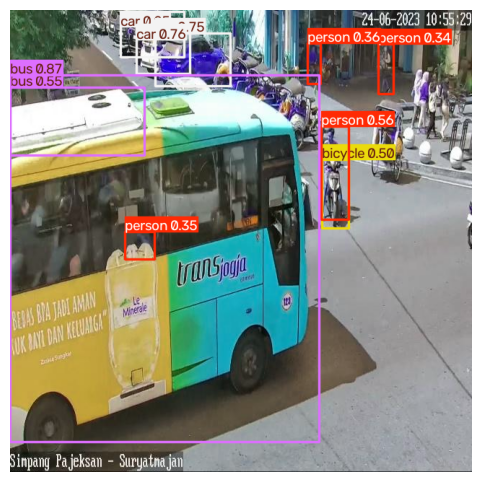

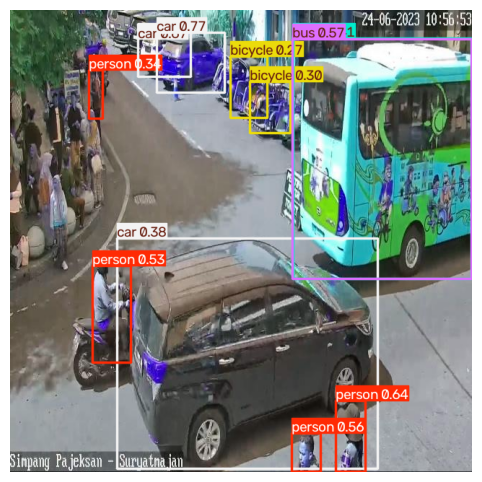

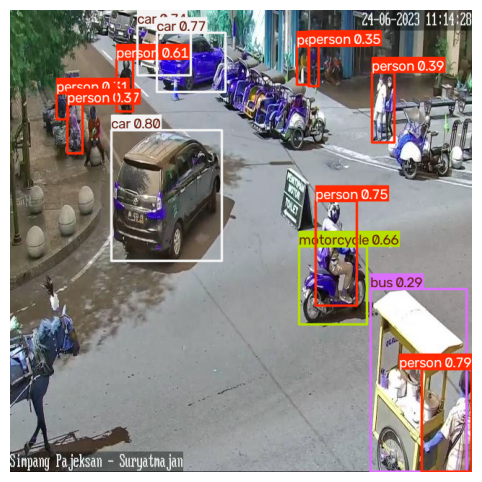

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

for result in results:
    annotated_image = result.plot()

    plt.figure(figsize=(8, 6))
    plt.imshow(annotated_image)
    plt.axis("off")
    plt.show()

In [ ]:
#Analysis: The pre-trained YOLOv8 model successfully detected vehicles present in the test images and drew bounding boxes around them.
#It also displayed confidence scores for each detected object.
#Images containing clear vehicles produced accurate detections, while images without recognizable objects resulted in fewer or no detections. 
#Overall, the model performed well for inference without requiring any additional training.